In [1]:
!pip install ipympl
%matplotlib widget

In [2]:
from pathlib import Path
import sys

current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

In [3]:
%pip install allensdk

  Using cached allensdk-2.16.2-py3-none-any.whl.metadata (1.9 kB)
  Using cached psycopg2_binary-2.9.11-cp312-cp312-win_amd64.whl.metadata (5.1 kB)
  Using cached hdmf-5.1.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "c:\ProgramData\anaconda3\envs\bgheatmap-env\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\ProgramData\anaconda3\envs\bgheatmap-env\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\ProgramData\anaconda3\envs\bgheatmap-env\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "c:\ProgramData\anaconda3\envs\bgheatmap-env\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_

In [4]:


from allensdk.core.mouse_connectivity_cache import MouseConnectivityCache

# --- A. Initialize the Cache ---
# This tells the SDK where to save the downloaded files (e.g., in a folder named 'ccf_data')
mcc = MouseConnectivityCache(manifest_file='ccf_data/mouse_connectivity_manifest.json')

# --- B. Download the 3D Annotation Volume (The "Atlas") ---
# resolution=25 means 25 microns per pixel (standard for most light sheet microscopy)
print("Loading Annotation Volume (this may take time on first run)...")
annotation_volume, meta = mcc.get_annotation_volume(resolution=25)

# --- C. Download the Structure Tree (The "Dictionary") ---
# This fetches the list of all region IDs, names, and acronyms
print("Loading Structure Tree...")
structure_tree = mcc.get_structure_tree()

# --- D. Convert to your 'structure_map' format ---
# We grab every known structure ID and format it into the dict your function expects
all_structure_ids = structure_tree.get_structure_ids()
all_structures = structure_tree.get_structures_by_id(all_structure_ids)

structure_map = {
    struct['id']: {
        'acronym': struct['acronym'], 
        'name': struct['name']
    }
    for struct in all_structures
}

print("Atlas loaded successfully.")

ModuleNotFoundError: No module named 'allensdk'

In [5]:
exp_path = r"Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29"
#volume = modeExtract(exp_path, mode="skeletonize")
volume = exp_path + "\downsampled_standard_skel.tif"
print(volume)
output_dir = exp_path + "\clusters"


print(output_dir)

Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\downsampled_standard_skel.tif
Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_82796\559598831.py:3: SyntaxWarning: invalid escape sequence '\d'
  volume = exp_path + "\downsampled_standard_skel.tif"
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_82796\559598831.py:5: SyntaxWarning: invalid escape sequence '\c'
  output_dir = exp_path + "\clusters"


In [6]:
pip install numpy matplotlib scikit-learn scikit-image pandas

Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from skimage.io import imread, imsave

def dbscan(
    input_tiff_path: str,
    output_dir: str,
    eps: float = 3.0,
    min_samples: int = 10,
    min_cluster_size: int = 50,
    fine_tune_metric: str = None
) -> tuple:
    """
    Loads a 3D TIFF stack, applies DBSCAN with optional grid search,
    saves individual clusters, and generates elbow and silhouette plots.
    """
    # --- 1. Setup Directories ---
    base_name = os.path.splitext(os.path.basename(input_tiff_path))[0]
    clusters_subdir = os.path.join(output_dir, f"{base_name}_clusters")

    if os.path.exists(clusters_subdir):
        shutil.rmtree(clusters_subdir)
    os.makedirs(clusters_subdir, exist_ok=True)

    # --- 2. Load Data ---
    if not os.path.exists(input_tiff_path):
        print(f"Error: File not found at {input_tiff_path}")
        return {}, {"eps": eps, "min_samples": min_samples}

    print(f"Loading TIFF: {input_tiff_path}")
    stack = imread(input_tiff_path)
    coords_tuple = np.nonzero(stack)
    points = np.stack(coords_tuple, axis=1)

    if len(points) == 0:
        print("Error: Input TIFF is empty (no foreground pixels found).")
        return {}, {"eps": eps, "min_samples": min_samples}

    # --- 3. Elbow Plot (K-Distance Plot) ---
    print("Generating Elbow Plot...")
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(points)
    distances, _ = neighbors_fit.kneighbors(points)
    sorted_distances = np.sort(distances[:, min_samples-1])

    plt.figure(figsize=(8, 5))
    plt.plot(sorted_distances, color='#1f77b4', lw=2)
    plt.title(f"DBSCAN Elbow Plot (k={min_samples})")
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{min_samples}-th NN Distance (Potential EPS)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(output_dir, f"{base_name}_elbow_plot.png"))
    plt.close()

    # --- 4. Custom Grid Search (Fine-Tuning) ---
    best_eps = eps
    best_min_samples = min_samples

    if fine_tune_metric == 'silhouette_score':
        print(f"Starting Grid Search for {base_name}...")
        eps_range = [eps * 0.75, eps, eps * 1.25, eps * 1.5]
        ms_range = [max(2, min_samples - 2), min_samples, min_samples + 5]
        best_overall_score = -1

        sample_size = min(len(points), 2000)
        rng = np.random.default_rng(42)
        idx = rng.choice(len(points), sample_size, replace=False)
        sample_pts = points[idx]

        for e in eps_range:
            for ms in ms_range:
                test_db = DBSCAN(eps=e, min_samples=ms).fit(points)
                test_labels = test_db.labels_
                n_c = len(set(test_labels)) - (1 if -1 in test_labels else 0)

                if n_c > 1:
                    score = silhouette_score(sample_pts, test_labels[idx])
                    if score > best_overall_score:
                        best_overall_score = score
                        best_eps, best_min_samples = e, ms

        print(f"Optimal Parameters: eps={best_eps:.2f}, min_samples={best_min_samples}")

    # --- 5. Final DBSCAN Run ---
    db = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit(points)
    labels = db.labels_
    unique_labels = sorted(list(set(labels) - {-1}))

    # --- 6. Calculate Silhouette Scores (Internal Map) ---
    label_to_score = {} 
    sample_silhouette_values = None
    avg_silhouette_score = None
    sampled_labels = None

    if len(unique_labels) > 1:
        # Sample for plotting and scoring (O(N^2) complexity safety)
        sample_size = min(len(points), 5000)
        idx = np.random.choice(len(points), sample_size, replace=False)
        
        sampled_points = points[idx]
        sampled_labels = labels[idx]
        
        avg_silhouette_score = silhouette_score(sampled_points, sampled_labels)
        sample_silhouette_values = silhouette_samples(sampled_points, sampled_labels)

        for label in unique_labels:
            mask = (sampled_labels == label)
            if np.any(mask):
                label_to_score[label] = np.mean(sample_silhouette_values[mask])
            else:
                label_to_score[label] = "Sample size too small"

    # --- 7. Save Clusters and Build Output Map ---
    cluster_score_map = {}
    for label in unique_labels:
        mask = (labels == label)
        if np.sum(mask) >= min_cluster_size:
            cluster_stack = np.zeros_like(stack, dtype=np.uint8)
            cluster_stack[coords_tuple[0][mask], coords_tuple[1][mask], coords_tuple[2][mask]] = 255
            
            filename = f"cluster_{label}_size_{np.sum(mask)}.tif"
            file_path = os.path.join(clusters_subdir, filename)
            imsave(file_path, cluster_stack, check_contrast=False)

            # Map the file path to the score for the visualization loop
            score = label_to_score.get(label, "N/A")
            cluster_score_map[file_path] = score

    # --- 8. Generate and Show Silhouette Plot ---
    if sample_silhouette_values is not None:
        print("Generating Silhouette Plot...")
        fig, ax1 = plt.subplots(1, 1, figsize=(12, 10))
        ax1.set_xlim([-0.1, 1])
        
        # Generous vertical spacing for many clusters
        ax1.set_ylim([0, len(sampled_labels) + (len(unique_labels) + 1) * 40])

        y_lower = 40 
        for i, label in enumerate(unique_labels):
            ith_cluster_silhouette_values = sample_silhouette_values[sampled_labels == label]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / len(unique_labels))
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            # Only label clusters that are thick enough to prevent text overlap
            if size_cluster_i > 40:
                ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(label), 
                         fontsize=10, va='center', fontweight='bold')
            
            y_lower = y_upper + 40 

        ax1.set_title(f"Silhouette Analysis: {base_name}\nAvg Silhouette Score: {avg_silhouette_score:.3f}")
        ax1.set_xlabel("Silhouette Coefficient Values")
        ax1.set_ylabel("Cluster Label")

        ax1.axvline(x=avg_silhouette_score, color="red", linestyle="--")
        ax1.set_yticks([]) 
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        ax1.grid(axis='x', linestyle=':', alpha=0.6)

        plt.tight_layout()
        plt.show() 
        plt.close()

    print(f"Workflow complete. Results saved in {output_dir}")
    print(f"Total valid clusters saved: {len(cluster_score_map)}")
    
    return cluster_score_map, {"eps": best_eps, "min_samples": best_min_samples}

Loading TIFF: Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\downsampled_standard_skel.tif
Generating Elbow Plot...
Starting Grid Search for downsampled_standard_skel...
Optimal Parameters: eps=4.50, min_samples=10
Generating Silhouette Plot...


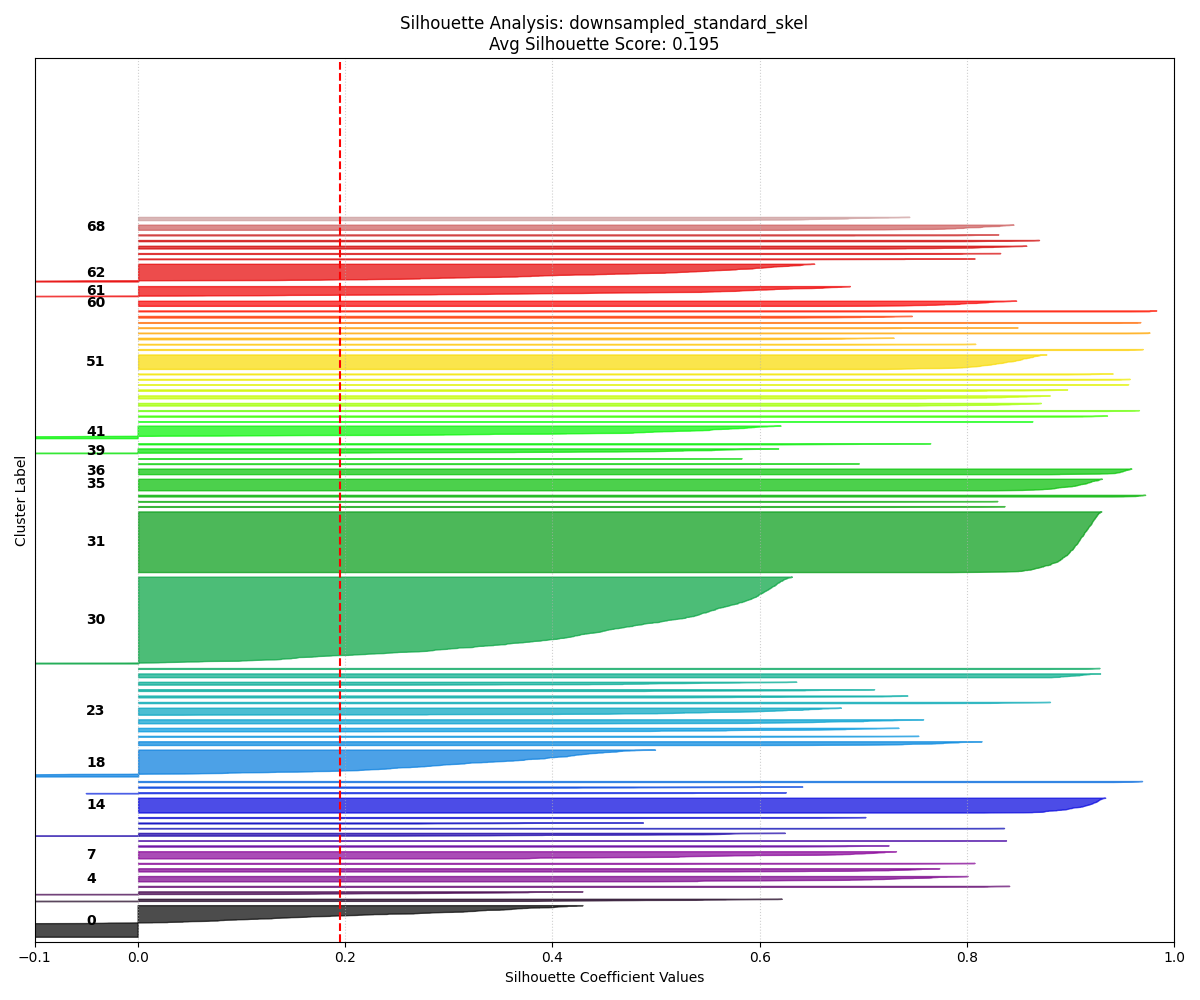

Workflow complete. Results saved in Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters
Total valid clusters saved: 20
------------------------------
FINAL RESULTS USING OPTIMAL PARAMETERS:
EPS: 4.50 | Min Samples: 10
------------------------------
Visualizing: cluster_0_size_444.tif
Cluster Silhouette Score: -0.0713


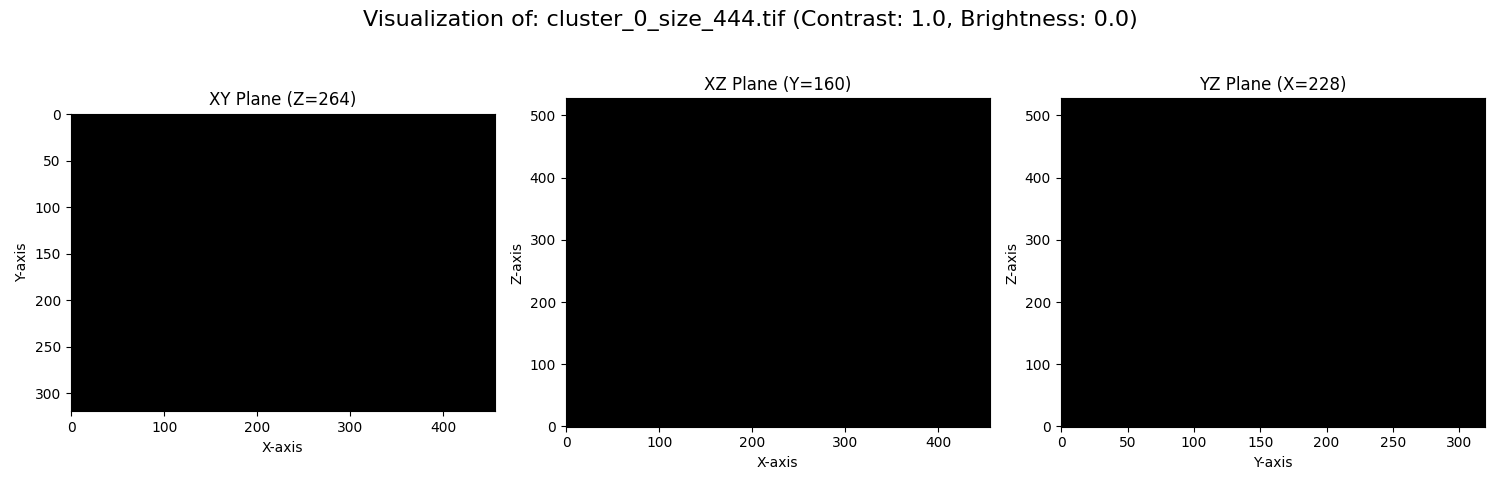

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_0_size_444.tif'.
Visualizing: cluster_4_size_73.tif
Cluster Silhouette Score: 0.6902


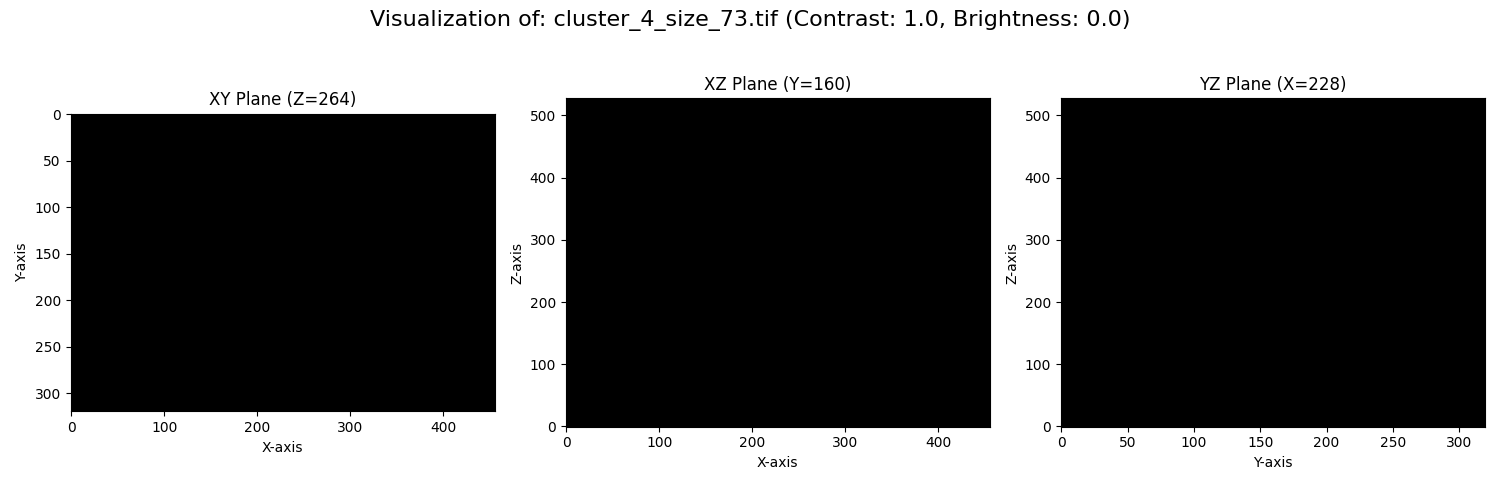

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_4_size_73.tif'.
Visualizing: cluster_5_size_59.tif
Cluster Silhouette Score: 0.7080


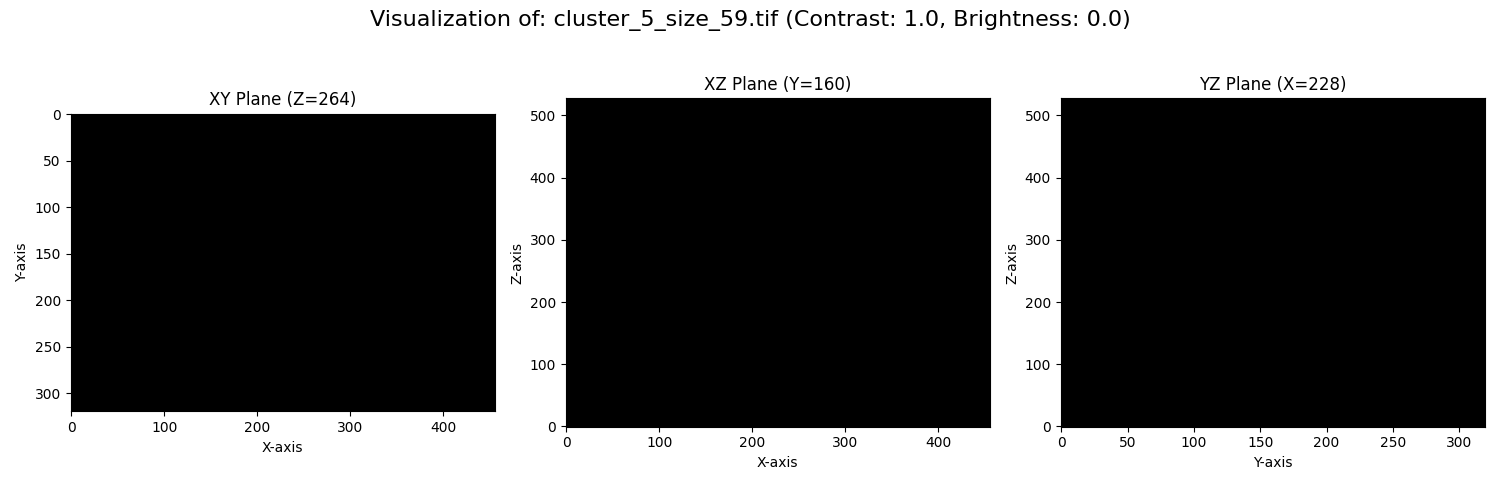

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_5_size_59.tif'.
Visualizing: cluster_7_size_105.tif
Cluster Silhouette Score: 0.5970


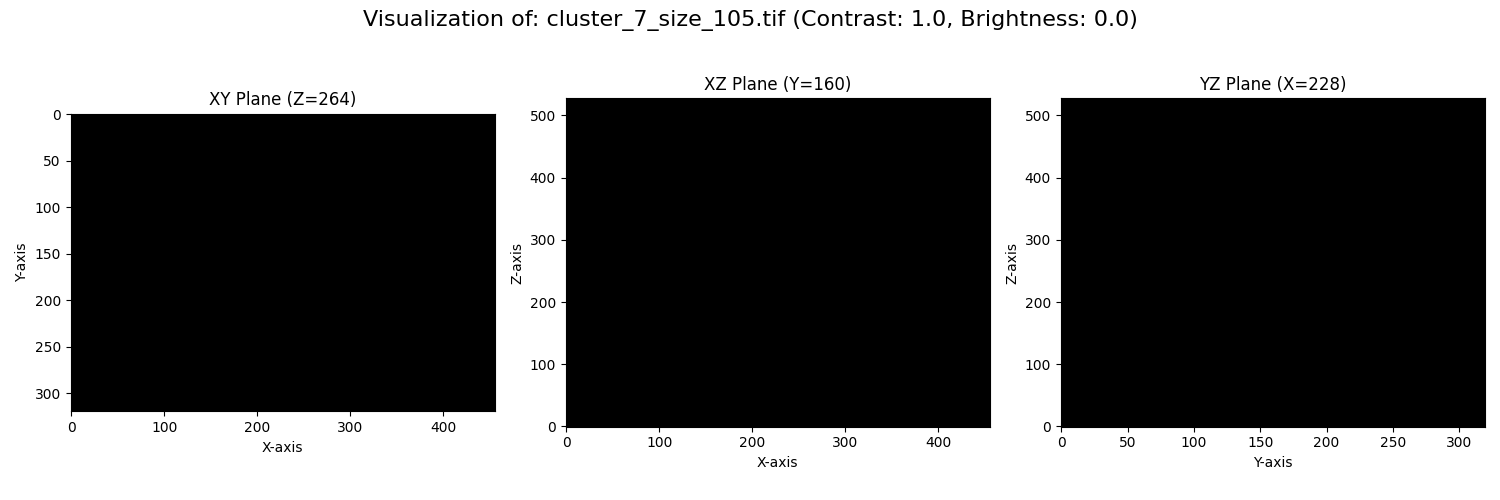

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_7_size_105.tif'.
Visualizing: cluster_14_size_217.tif
Cluster Silhouette Score: 0.9083


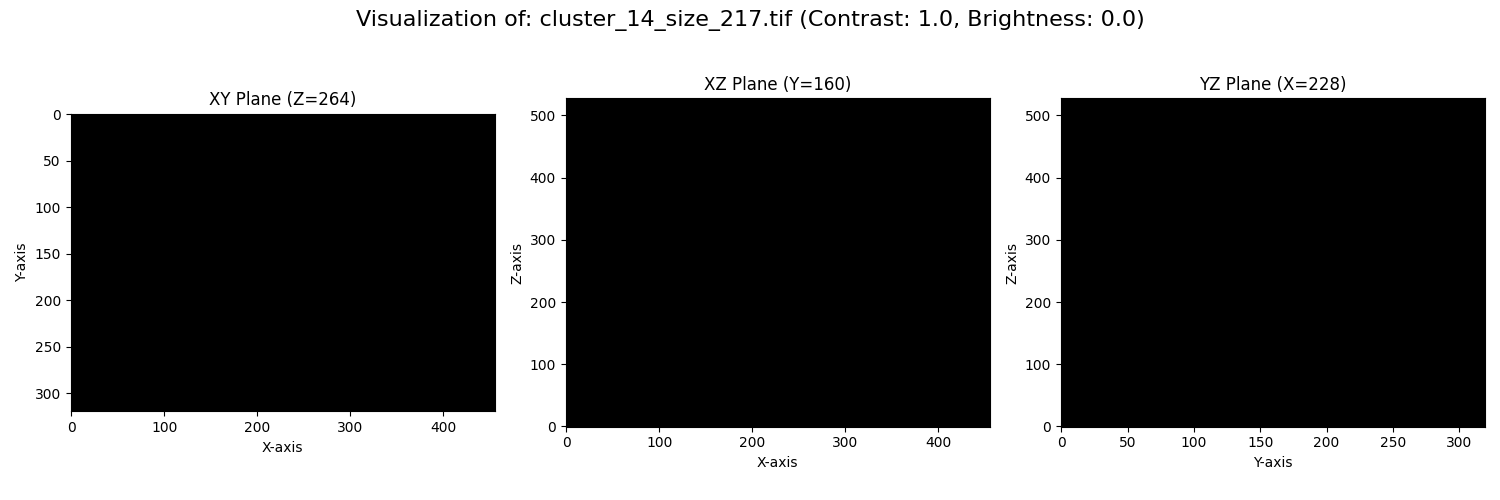

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_14_size_217.tif'.
Visualizing: cluster_18_size_381.tif
Cluster Silhouette Score: 0.2675


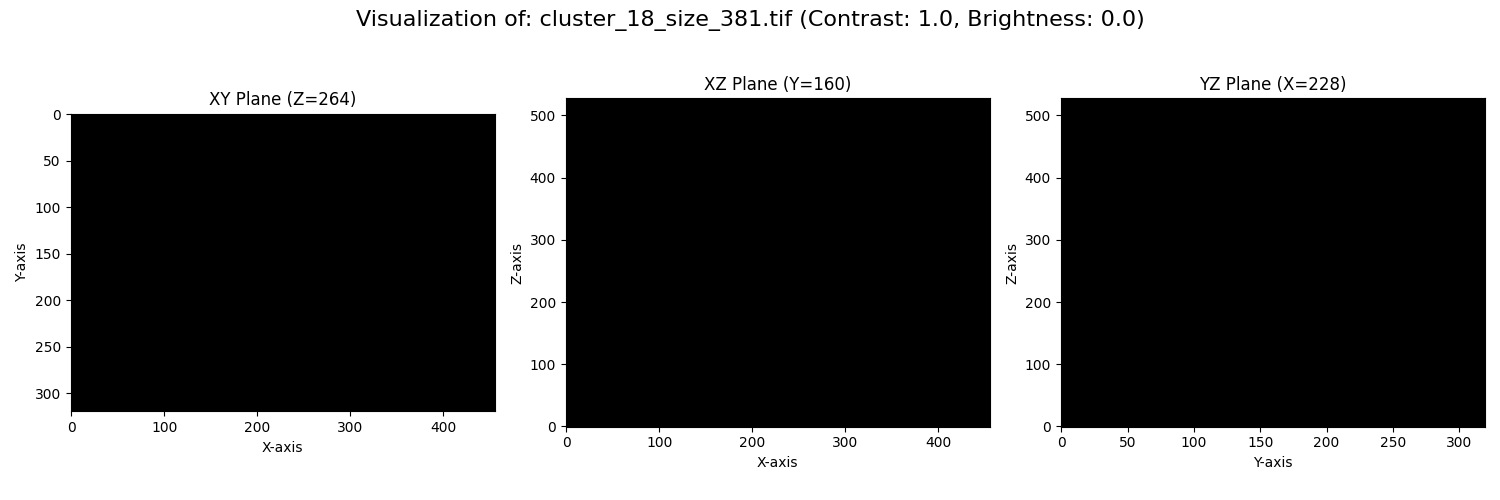

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_18_size_381.tif'.
Visualizing: cluster_19_size_56.tif
Cluster Silhouette Score: 0.7580


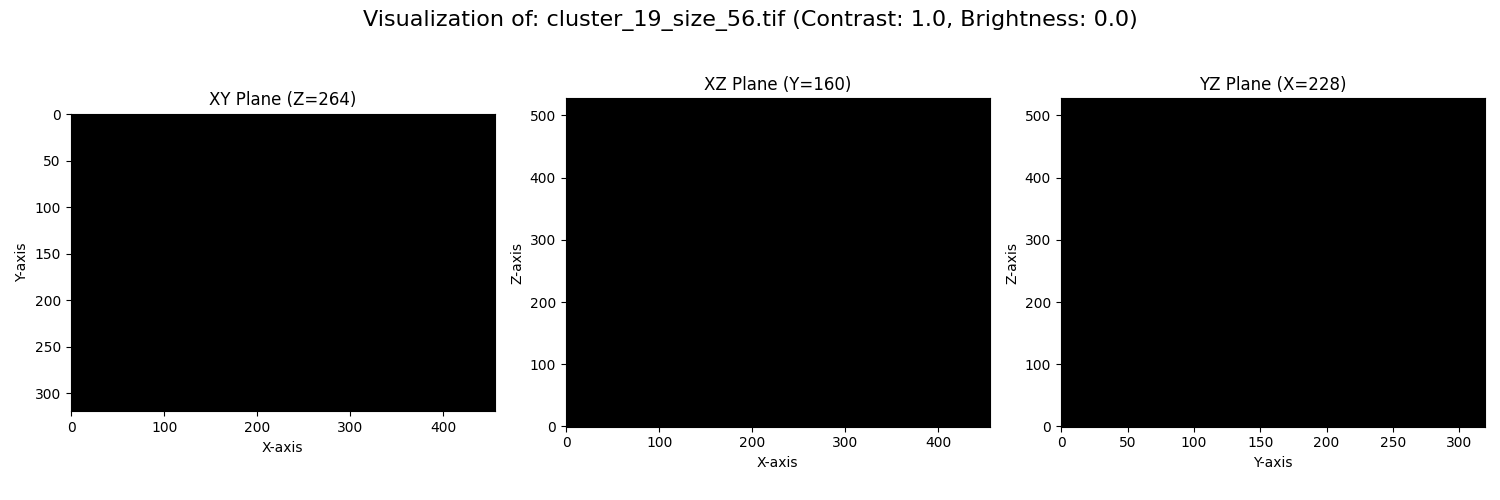

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_19_size_56.tif'.
Visualizing: cluster_21_size_51.tif
Cluster Silhouette Score: 0.6000


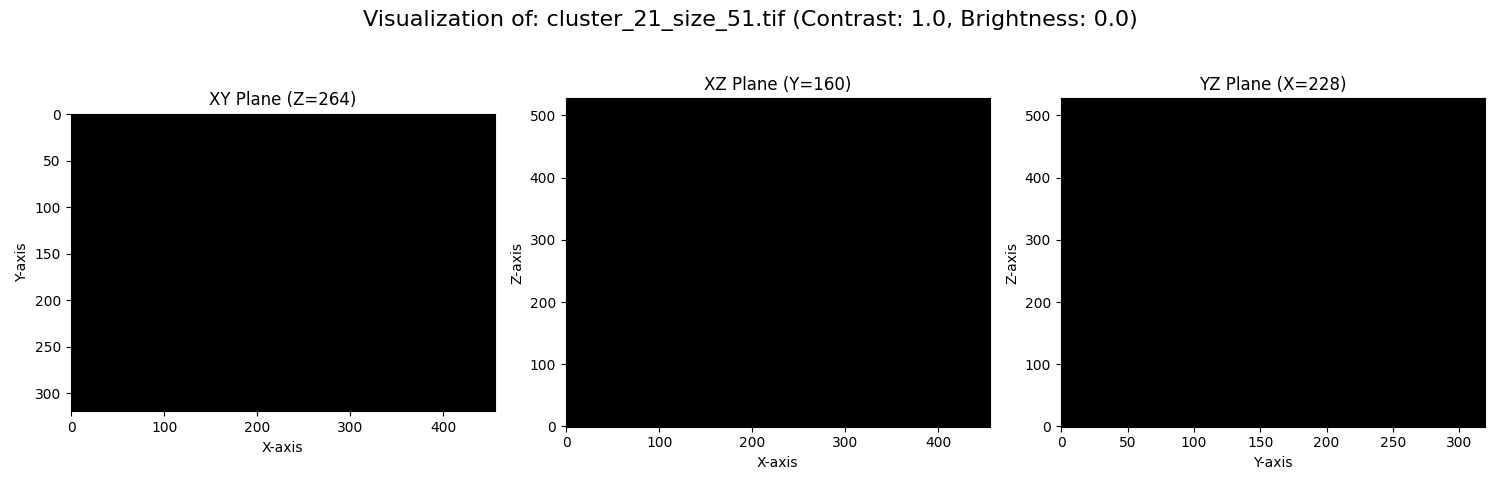

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_21_size_51.tif'.
Visualizing: cluster_23_size_101.tif
Cluster Silhouette Score: 0.5452


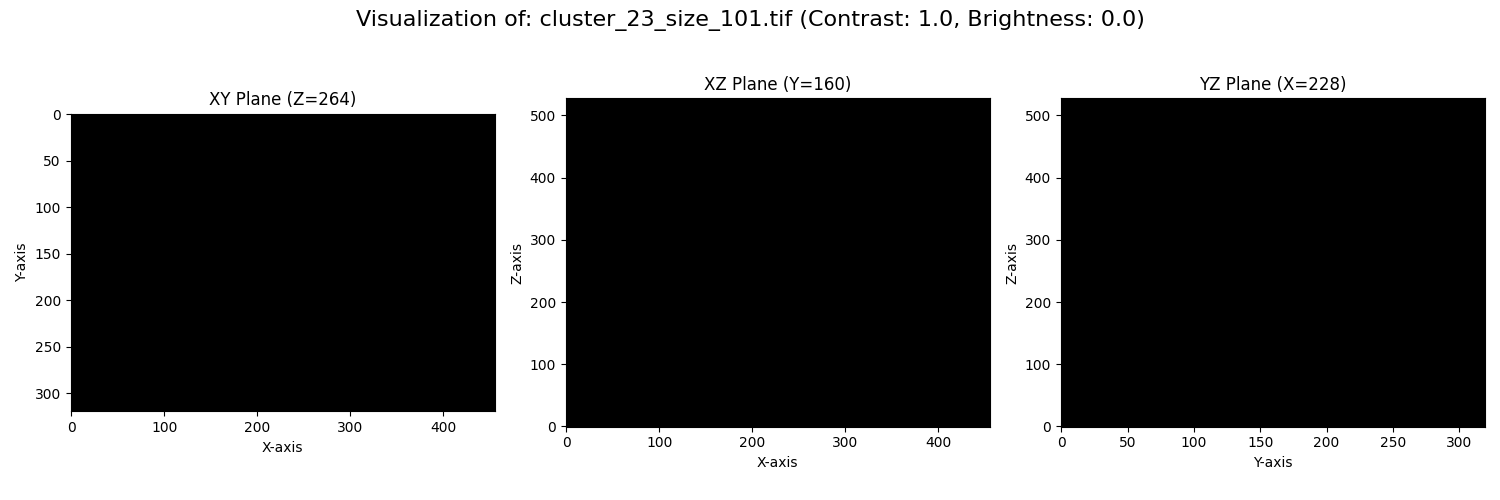

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_23_size_101.tif'.
Visualizing: cluster_30_size_1257.tif
Cluster Silhouette Score: 0.4577


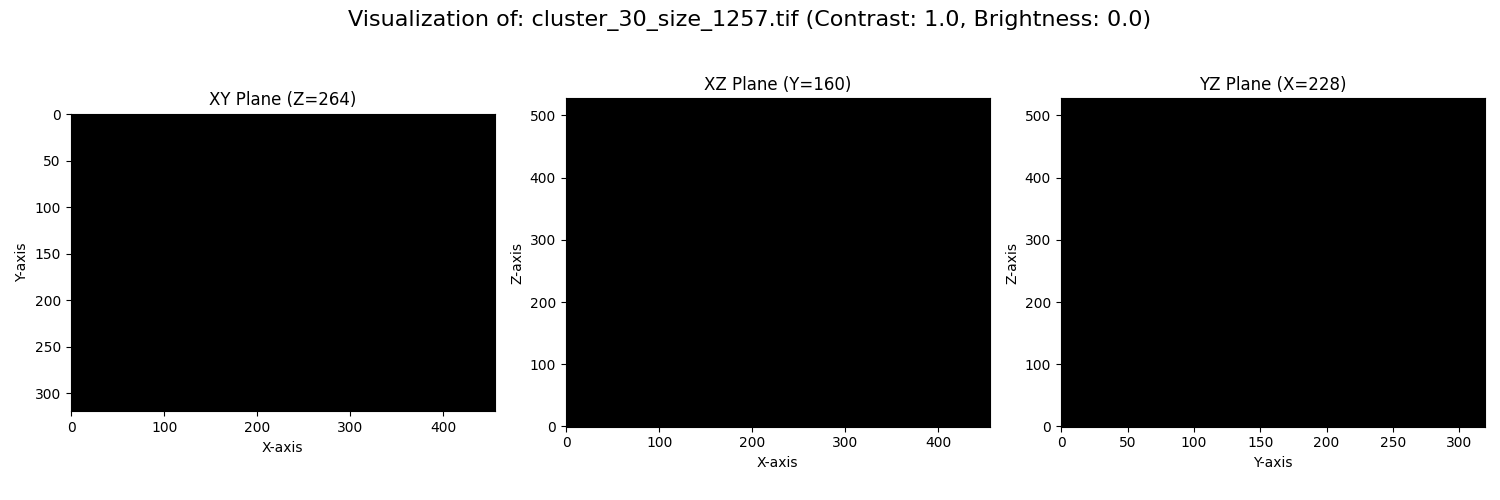

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_30_size_1257.tif'.
Visualizing: cluster_31_size_893.tif
Cluster Silhouette Score: 0.9027


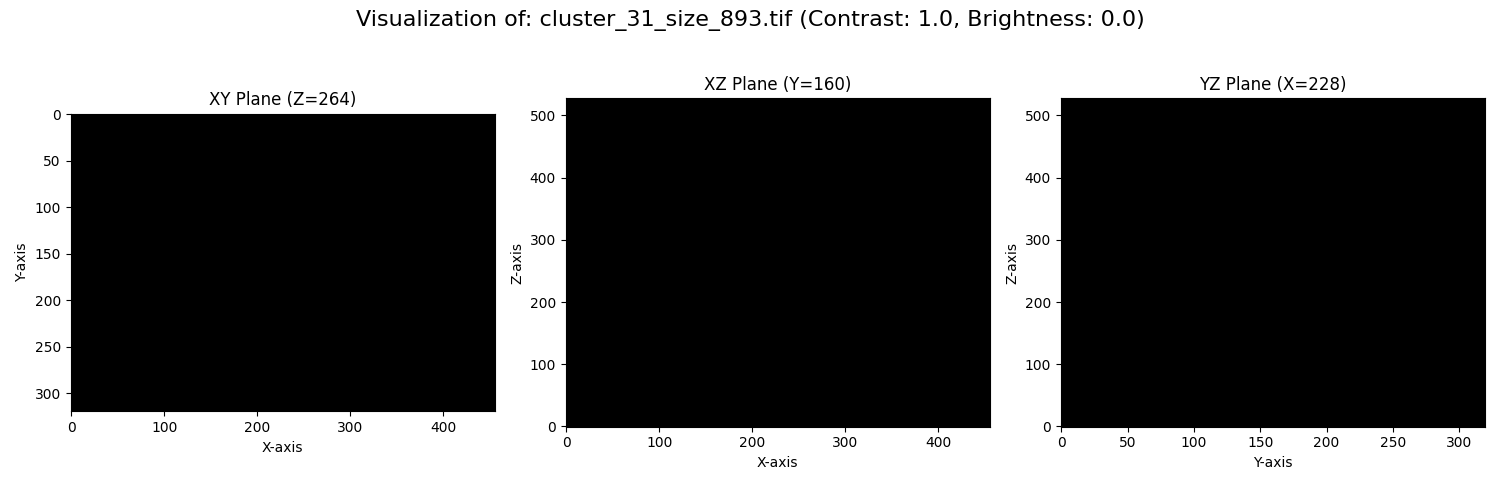

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_31_size_893.tif'.
Visualizing: cluster_35_size_172.tif
Cluster Silhouette Score: 0.9029


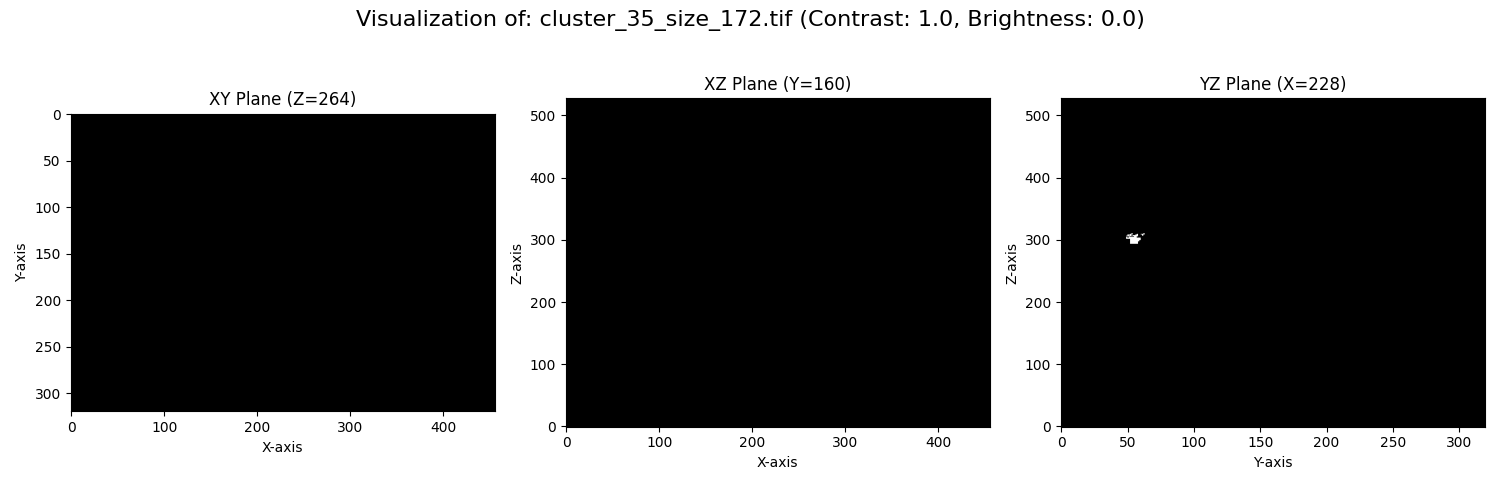

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_35_size_172.tif'.
Visualizing: cluster_36_size_88.tif
Cluster Silhouette Score: 0.9436


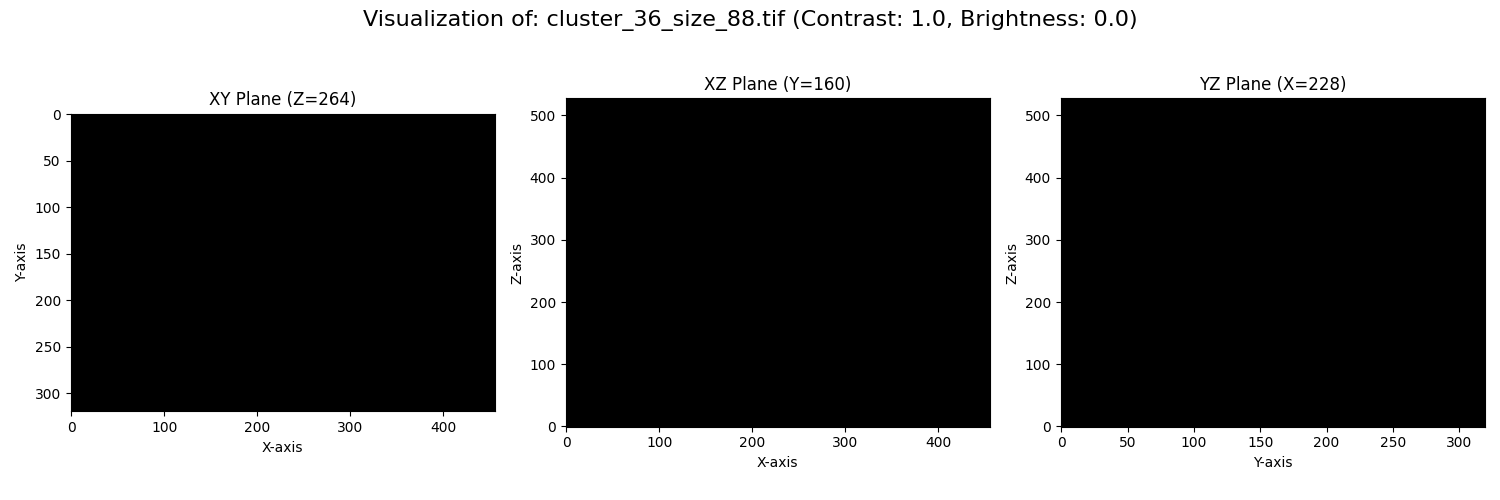

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_36_size_88.tif'.
Visualizing: cluster_39_size_77.tif
Cluster Silhouette Score: 0.3945


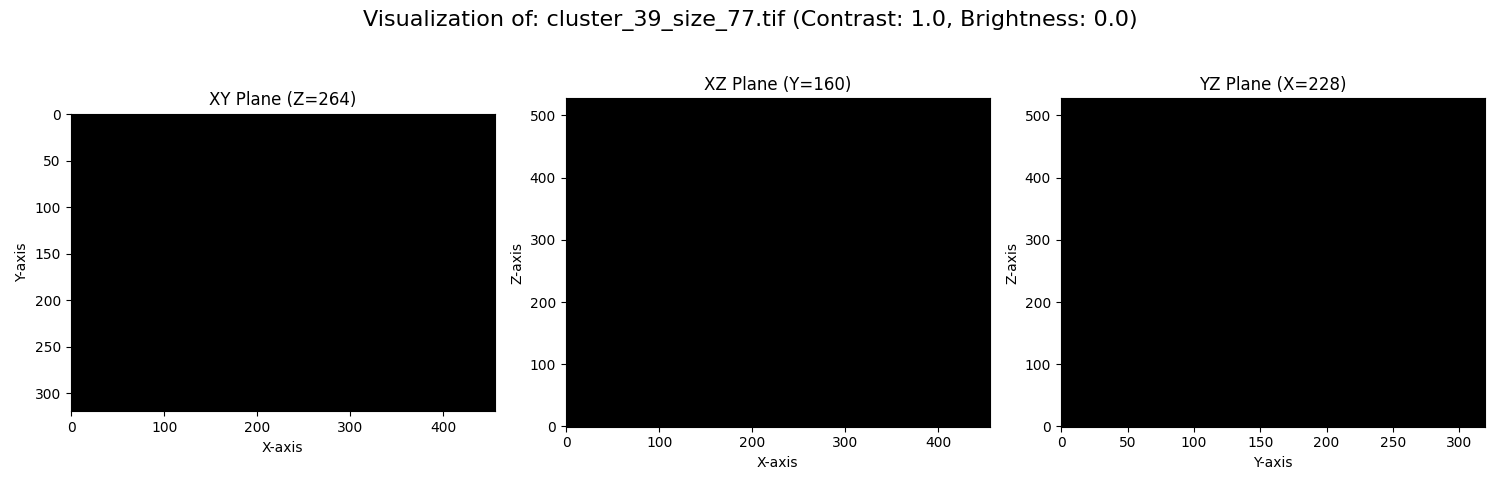

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_39_size_77.tif'.
Visualizing: cluster_41_size_188.tif
Cluster Silhouette Score: 0.3320


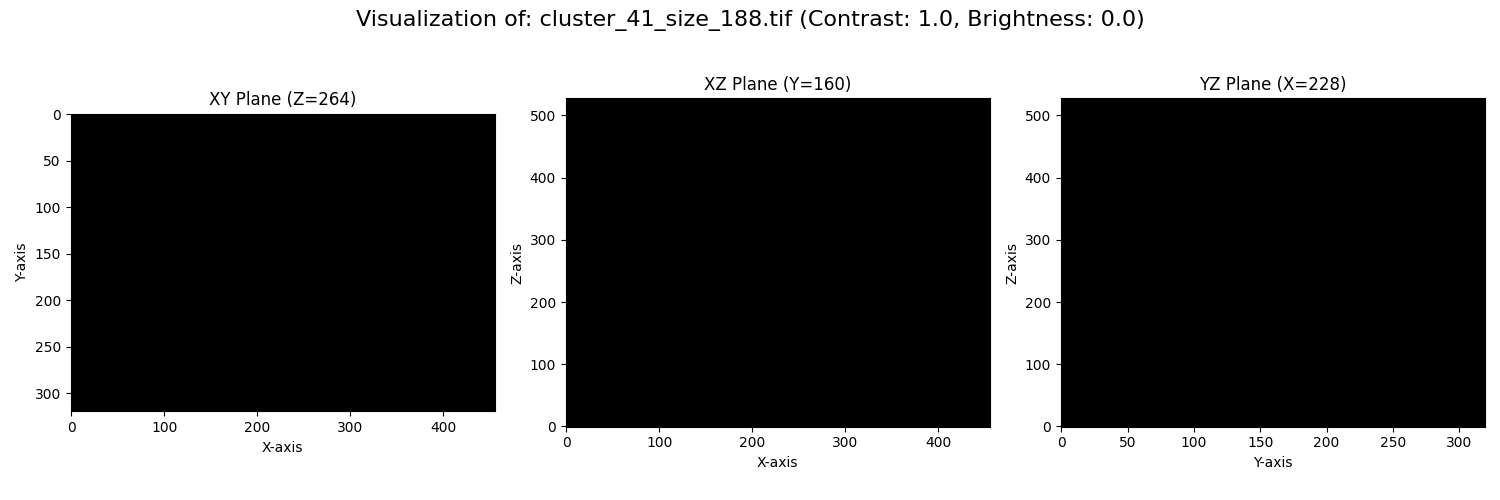

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_41_size_188.tif'.
Visualizing: cluster_51_size_205.tif
Cluster Silhouette Score: 0.8320


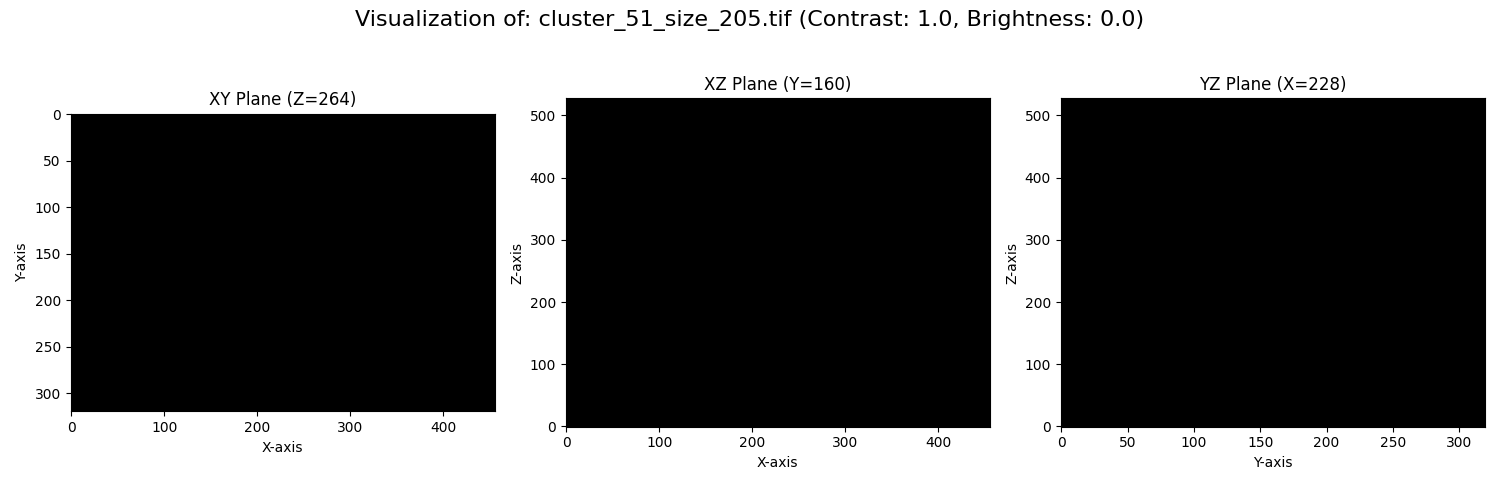

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_51_size_205.tif'.
Visualizing: cluster_60_size_60.tif
Cluster Silhouette Score: 0.7914


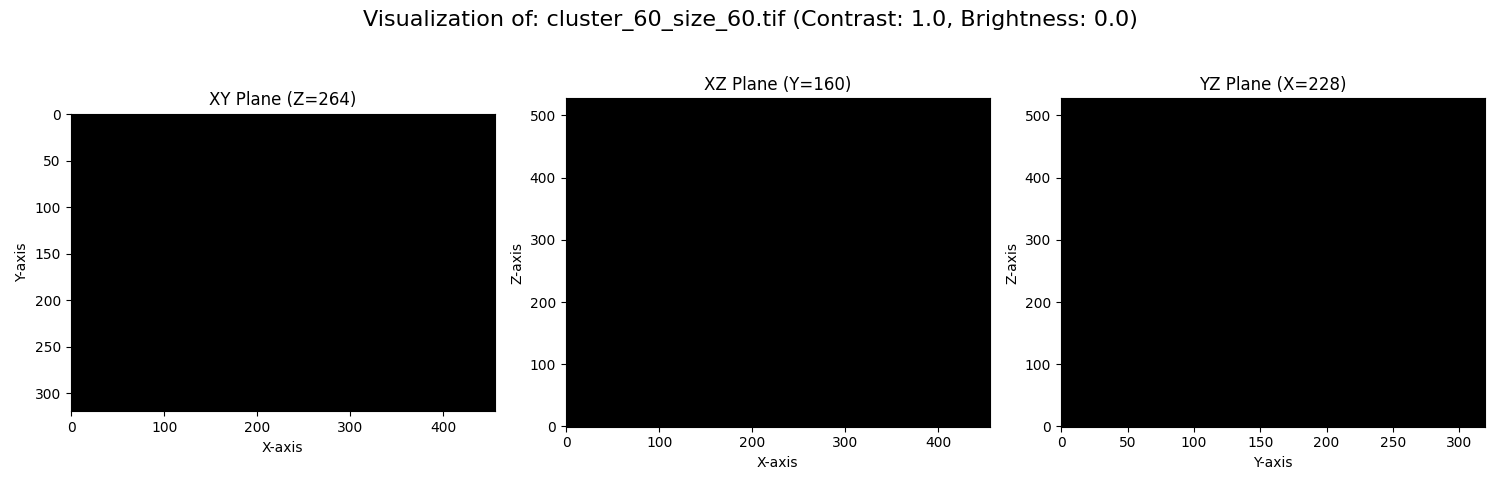

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_60_size_60.tif'.
Visualizing: cluster_61_size_134.tif
Cluster Silhouette Score: 0.4648


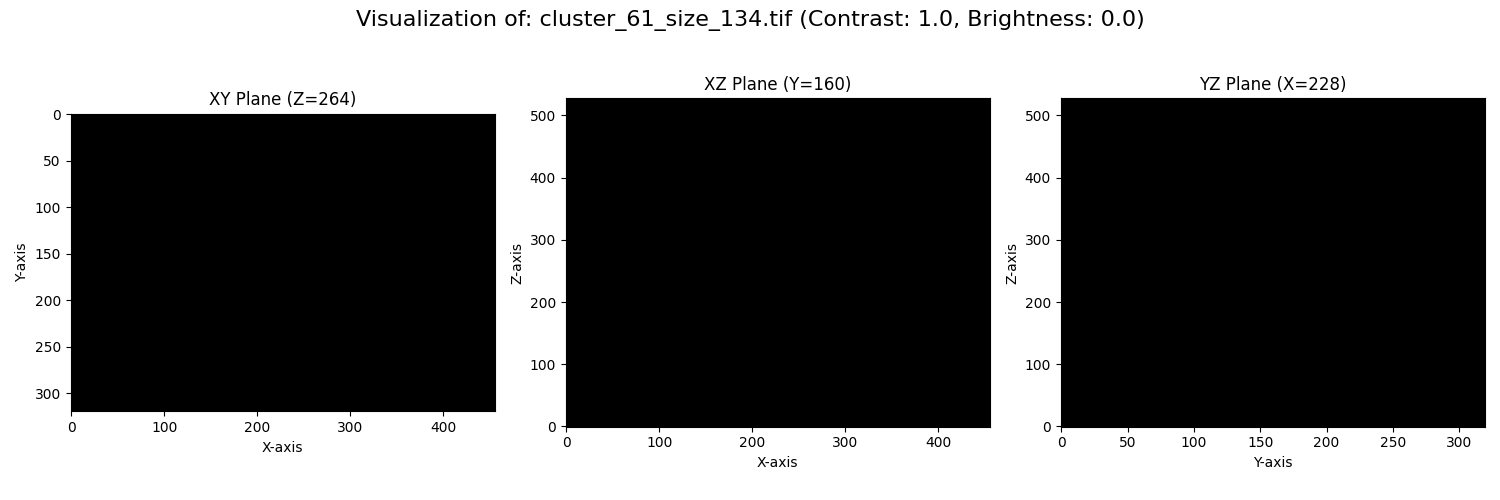

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_61_size_134.tif'.
Visualizing: cluster_62_size_264.tif
Cluster Silhouette Score: 0.4311


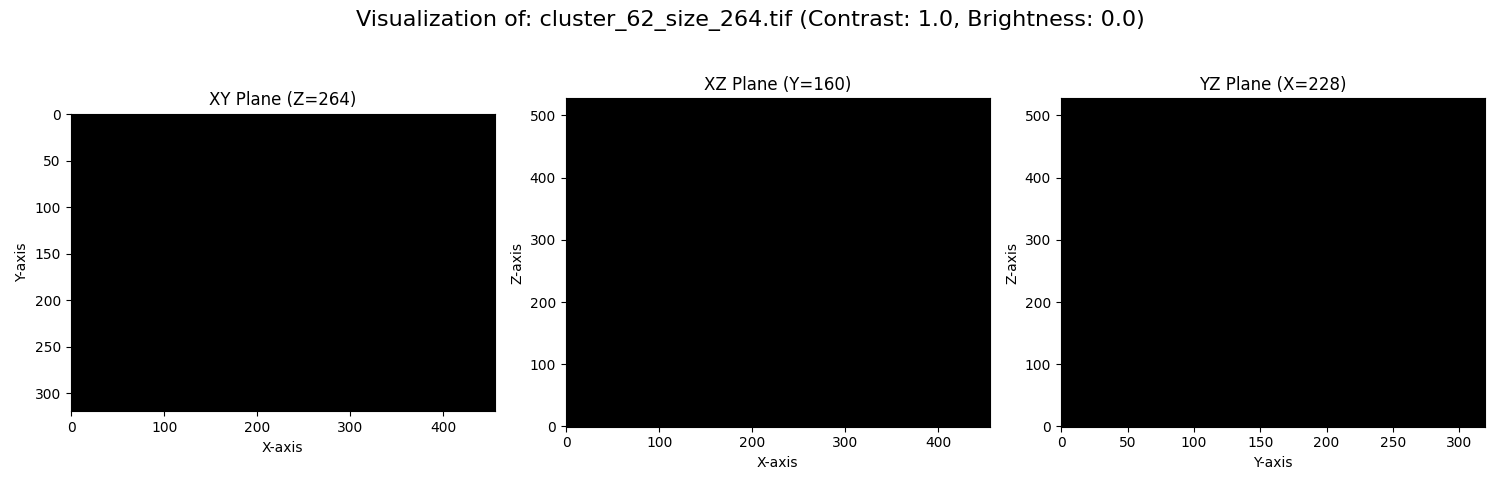

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_62_size_264.tif'.
Visualizing: cluster_68_size_77.tif
Cluster Silhouette Score: 0.7902


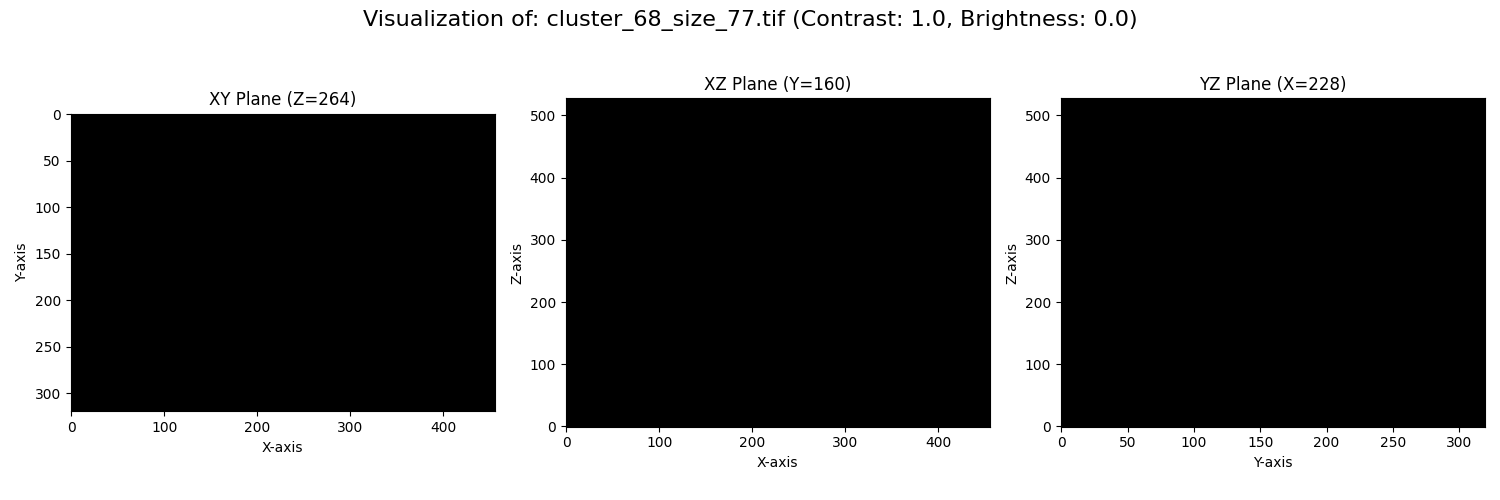

Successfully visualized 'Z:\anatomy_histology\UTSW_brains\UTSW_sample_5_ch0_2_26_2026-03-23_11-11-29\clusters\downsampled_standard_skel_clusters\cluster_68_size_77.tif'.


In [8]:
from lib.auxilary import *

# 1. Run the function and capture the new return values
dbscan_results, optimal_params = dbscan(volume, output_dir, fine_tune_metric='silhouette_score')

# 2. Print the global optimal parameters once
print("-" * 30)
print(f"FINAL RESULTS USING OPTIMAL PARAMETERS:")
print(f"EPS: {optimal_params['eps']:.2f} | Min Samples: {optimal_params['min_samples']}")
print("-" * 30)

# 3. Loop through and visualize
for path, score in dbscan_results.items():
    # Formatting the score if it's a float, handling "N/A" strings safely
    score_display = f"{score:.4f}" if isinstance(score, float) else score
    
    print(f"Visualizing: {os.path.basename(path)}")
    print(f"Cluster Silhouette Score: {score_display}")

    # Ensure tiffVisualize is defined (see previous response)
    tiffVisualize(path, colormap="bone", views=3)

In [9]:
!pip install scikit-image

In [10]:
import numpy as np
import os
from skimage.io import imread
from skimage.morphology import skeletonize
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

def convert_tiff_to_swc(tiff_path: str, swc_output_path: str, voxel_size=(1, 1, 1)):
    """
    Converts TIFF to SWC, forces connectivity, and scales coordinates by 25.
    """
    # 1. Load data
    stack = imread(tiff_path)
    if np.max(stack) == 0:
        return 
    
    # 2. Skeletonize
    binary_stack = stack > 0
    skeleton = skeletonize(binary_stack)
    
    # 3. Extract coordinates
    z, y, x = np.nonzero(skeleton)
    points = np.stack((z, y, x), axis=1).astype(float)
    points = np.unique(points, axis=0)
    
    if len(points) < 2:
        return

    # 4. Force connectivity (MST)
    dist_mat = distance_matrix(points, points)
    mst = minimum_spanning_tree(dist_mat)
    sources, targets = mst.nonzero()

    parent_map = {i: -1 for i in range(len(points))}
    for s, t in zip(sources, targets):
        parent_map[t] = s + 1 

    # 5. Write SWC with 25x scaling
    scaling_factor = 25
    
    with open(swc_output_path, 'w') as f:
        f.write("# id type x y z r parent\n")
        for i, pt in enumerate(points):
            node_id = i + 1
            node_type = 1 if i == 0 else 3
            
            # Apply voxel size AND the 25x multiplier
            xx = pt[2] * voxel_size[2] * scaling_factor
            yy = pt[1] * voxel_size[1] * scaling_factor
            zz = pt[0] * voxel_size[0] * scaling_factor
            
            r = 1.5 
            parent = parent_map[i]
            
            f.write(f"{int(node_id)} {int(node_type)} {xx:.3f} {yy:.3f} {zz:.3f} {r:.1f} {int(parent)}\n")

    print(f"Successfully created: {os.path.basename(swc_output_path)} (Scaled 25x)")

In [13]:
# Assuming 'cluster_score_map' came from your dbscan output
for tiff_path in cluster_score_map.keys():
    swc_path = tiff_path.replace(".tif", ".swc")
    convert_tiff_to_swc(tiff_path, swc_path)


NameError: name 'cluster_score_map' is not defined

In [12]:
print(dbscan_stacks)

NameError: name 'dbscan_stacks' is not defined

In [14]:
#output_path = os.path.join(exp_path, "connections_dbscan.tif")
#con_stack = connections(dbscan_stacks[16], exp_path)

# Create a specific output folder so files don't get lost
output_dir = os.path.join(exp_path, "dbscan_results")
os.makedirs(output_dir, exist_ok=True)

for i in range(len(dbscan_stacks)):
    # Fix: Pass 'filename_prefix' so files don't overwrite each other!
    # When calling on a single array:
# The function now returns 3 things: (stack, tif_path, csv_path)
# We use _ to ignore the paths if you only want the stack for combination
    current_con, _, _ = connections(dbscan_stacks[i], output_dir=output_dir, filename_prefix=f"cluster_{i:02d}")
    
    print(f"Processed cluster {i}")

NameError: name 'dbscan_stacks' is not defined

In [7]:
import pandas as pd
from pathlib import Path

def create_encoded_csv(input_path):
    """
    Reads a CSV, one-hot encodes 'structure' and 'structure_hemisphere',
    and saves the result as a new CSV file in the same directory.
    """
    # Convert string path to a Path object for easy naming
    path = Path(input_path)
    
    # Load the dataset
    df = pd.read_csv(path)
    
    # Define columns to encode based on your brain anatomy data
    target_columns = ['structure', 'structure_hemisphere']
    
    # Check if columns exist before encoding to avoid errors
    cols_to_use = [col for col in target_columns if col in df.columns]
    
    # Generate one-hot encoded columns (0/1 integers)
    df_encoded = pd.get_dummies(df, columns=cols_to_use, dtype=int)
    
    # Create the new filename (e.g., 'my_data.csv' -> 'my_data_encoded.csv')
    output_filename = f"{path.stem}_encoded{path.suffix}"
    output_path = path.parent / output_filename
    
    # Save the new file
    df_encoded.to_csv(output_path, index=False)
    
    print(f"Success! Encoded file saved to: {output_path}")
    return str(output_path)

# Example usage:
new_file = create_encoded_csv(r"Z:\anatomy_histology\mouselight\gpe\swc_coordinate.csv")

Success! Encoded file saved to: Z:\anatomy_histology\mouselight\gpe\swc_coordinate_encoded.csv


Using features: ['structure_ACAd1', 'structure_ACAd2/3', 'structure_ACAd5', 'structure_ACAd6a', 'structure_ACAd6b', 'structure_ACAv1', 'structure_ACAv2/3', 'structure_ACAv5', 'structure_ACAv6a', 'structure_ACAv6b', 'structure_ACB', 'structure_AHN', 'structure_AId6a', 'structure_AId6b', 'structure_AIp2/3', 'structure_AIp5', 'structure_AIp6a', 'structure_AIv1', 'structure_AIv2/3', 'structure_AIv5', 'structure_AIv6a', 'structure_AOBgr', 'structure_AON', 'structure_APN', 'structure_AQ', 'structure_BLAa', 'structure_CA1', 'structure_CA2', 'structure_CA3', 'structure_CEAc', 'structure_CEAm', 'structure_CL', 'structure_CLA', 'structure_CLI', 'structure_CM', 'structure_CP', 'structure_CTXsp', 'structure_DG-mo', 'structure_DG-po', 'structure_DG-sg', 'structure_DMH', 'structure_DP', 'structure_EPd', 'structure_EW', 'structure_Eth', 'structure_FC', 'structure_FF', 'structure_FRP1', 'structure_FRP5', 'structure_FRP6a', 'structure_GPe', 'structure_GPi', 'structure_GU1', 'structure_GU2/3', 'structur

C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_75264\1529352180.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster'] = KMeans(n_clusters=opt_k, random_state=random_state, n_init=10).fit_predict(X_scaled)


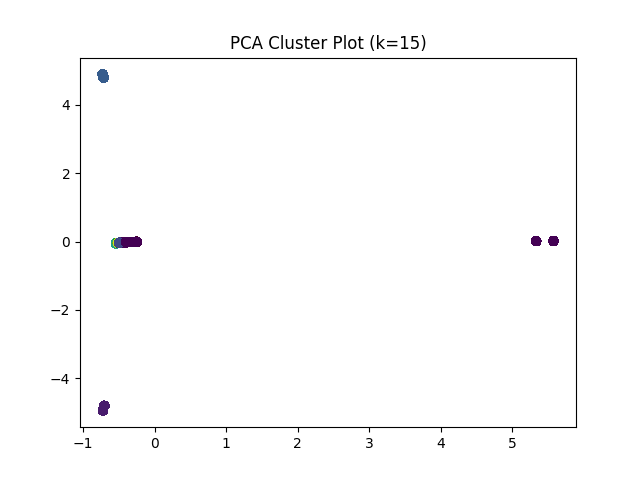

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurom as nm
from neurom import view
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def cluster_neurons_from_csv(csv_path, swc_folder, k_range=(2, 15), random_state=42):
    # 1. Load the encoded data
    df = pd.read_csv(csv_path)
    
    # OLD WAY: exclude_cols = [...] (Fragile if new string columns appear)
    # NEW WAY: Automatically grab only integers and floats for the model
    X = df.select_dtypes(include=[np.number])
    
    # Optional: If you still want to exclude coordinates (x, y, z) 
    # so they don't bias the "shape" clustering:
    coords_to_drop = ['x', 'y', 'z', 'soma_id']
    X = X.drop(columns=[c for c in coords_to_drop if c in X.columns])
    
    print(f"Using features: {X.columns.tolist()}")

    # 2. Scaling (This will now work!)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ... [Rest of your Elbow/Silhouette logic remains the same] ...
    
    # 3. Running the final KMeans
    ks = range(k_range[0], min(k_range[1] + 1, len(df)))
    wcss, sil_scores = [], []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X_scaled, labels))

    # [Elbow/Silhouette Plots code here]
    
    opt_k = ks[np.argmax(sil_scores)]
    df['cluster'] = KMeans(n_clusters=opt_k, random_state=random_state, n_init=10).fit_predict(X_scaled)
    
    # Visualizing (PCA handles the high-dim one-hot data)
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    plt.scatter(components[:, 0], components[:, 1], c=df['cluster'], cmap='viridis')
    plt.title(f"PCA Cluster Plot (k={opt_k})")
    plt.show()

    return df

def visualize_cluster_samples(df, swc_folder, n_clusters):
    """Plots a sample SWC from each cluster using NeuroM."""
    fig = plt.figure(figsize=(15, 5))
    
    for i in range(n_clusters):
        cluster_samples = df[df['cluster'] == i]
        if cluster_samples.empty: continue
        
        # Get the first SWC file in this cluster
        # Using 'swc_name' or 'file_name' from your CSV
        sample_file = cluster_samples.iloc[0]['swc_name'] 
        if not sample_file.endswith('.swc'):
            sample_file += '.swc'
            
        full_path = os.path.join(swc_folder, sample_file)
        
        if os.path.exists(full_path):
            ax = fig.add_subplot(1, n_clusters, i + 1)
            m = nm.load_morphology(full_path)
            view.plot_morph(m, ax, color='black', alpha=0.8)
            ax.set_title(f"Cluster {i}")
            ax.axis('off')
            
    plt.suptitle("Representative Morphologies by Cluster", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- Usage Example ---
processed_df = cluster_neurons_from_csv(
    csv_path=r"Z:\anatomy_histology\mouselight\gpe\swc_coordinate_encoded.csv", 
    swc_folder=r"Z:\anatomy_histology\mouselight\gpe"
)

Processing 163 neurons...


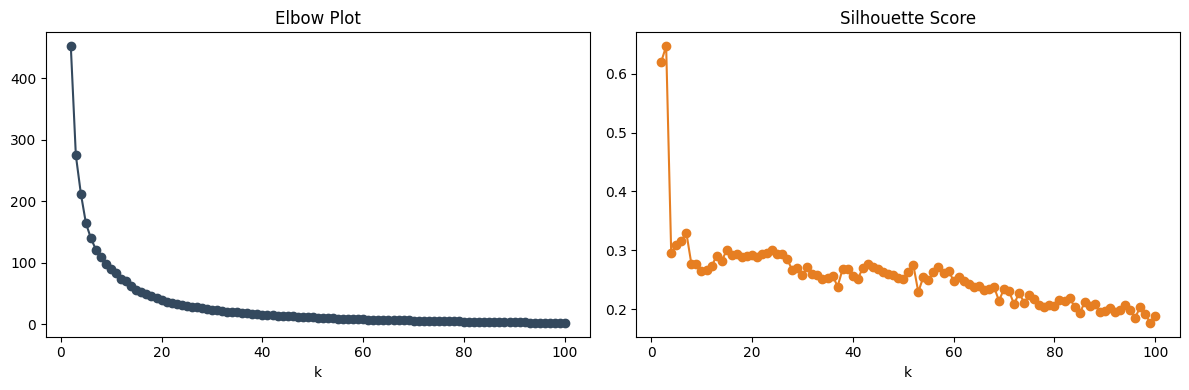

Clustering complete. Optimal clusters: 3
Moving 145 files to Z:\anatomy_histology\mouselight\SNr_163_CLUSTERED\clusterfolder0...
Moving 5 files to Z:\anatomy_histology\mouselight\SNr_163_CLUSTERED\clusterfolder2...
Moving 10 files to Z:\anatomy_histology\mouselight\SNr_163_CLUSTERED\clusterfolder1...

File distribution complete.


In [8]:
import os
import shutil

def distribute_clusters(df, source_folder, output_root):
    """
    Creates directories for each cluster and copies SWC files into them.
    """
    if df is None or df.empty:
        print("No data to distribute.")
        return

    # 1. Create the root output directory if it doesn't exist
    if not os.path.exists(output_root):
        os.makedirs(output_root)
        print(f"Created root directory: {output_root}")

    # 2. Iterate through the unique clusters found
    clusters = df['cluster'].unique()
    for c in clusters:
        cluster_dir = os.path.join(output_root, f"clusterfolder{c}")
        os.makedirs(cluster_dir, exist_ok=True)
        
        # Filter dataframe for this specific cluster
        cluster_files = df[df['cluster'] == c]['file_name']
        
        print(f"Moving {len(cluster_files)} files to {cluster_dir}...")
        
        for file_name in cluster_files:
            src_path = os.path.join(source_folder, file_name)
            dst_path = os.path.join(cluster_dir, file_name)
            
            try:
                # Use copy2 to preserve metadata (timestamps, etc.)
                shutil.copy2(src_path, dst_path)
            except Exception as e:
                print(f"Failed to copy {file_name}: {e}")

    print("\nFile distribution complete.")

# --- How to run the full pipeline ---

# 1. Run the clustering method first
source_dir = r"Z:\anatomy_histology\mouselight\SNr_163"
results_df = kmeans_cluster_mouselight_swc(source_dir)

# 2. Distribute the files into folders
if results_df is not None:
    # Set your desired output location
    output_dir = r"Z:\anatomy_histology\mouselight\SNr_163_CLUSTERED"
    distribute_clusters(results_df, source_dir, output_dir)

In [3]:
import vedo
import os
import random
from brainrender import Scene
from brainrender.actors import Neuron

# Force 'qt' backend for the pop-up window
vedo.settings.default_backend = 'qt' 

def get_random_hex_color():
    """Generates a random hex color string."""
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

def render_clustered_neurons(clustered_root_dir):
    """
    Renders SWCs from cluster folders, giving each cluster a unique color.
    """
    scene = Scene(title="Clustered SWC Visualization")
    
    # Get all subdirectories (clusterfolder0, clusterfolder1, etc.)
    cluster_folders = [f for f in os.listdir(clustered_root_dir) 
                       if os.path.isdir(os.path.join(clustered_root_dir, f))]
    
    print(f"Found {len(cluster_folders)} clusters for rendering.")

    for folder_name in cluster_folders:
        folder_path = os.path.join(clustered_root_dir, folder_name)
        
        # Assign one unique color to this entire cluster
        cluster_color = get_random_hex_color()
        print(f"Assigning color {cluster_color} to {folder_name}")
        
        # Get all SWC files in this specific cluster folder
        swc_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.swc')]
        
        for swc_file in swc_files:
            full_path = os.path.join(folder_path, swc_file)
            try:
                neuron = Neuron(
                    full_path,
                    color=cluster_color,
                    alpha=0.6 # Slightly higher alpha to see bundles clearly
                )
                scene.add(neuron)
            except Exception as e:
                print(f"Could not render {swc_file}: {e}")

    # Add relevant brain regions for context (e.g., SNr or GPe)
    scene.add_brain_region('SNr', alpha=0.15, color='grey')
    scene.add_brain_region('GPe', alpha=0.1, color='lightgrey')
    
    print("Rendering scene... check for pop-up window.")
    scene.render()

# --- Run the Visualization ---
# Use the 'output_root' directory from your previous distribution step
clustered_dir = r"Z:\anatomy_histology\mouselight\SNr_163_CLUSTERED"
render_clustered_neurons(clustered_dir)

Found 3 clusters for rendering.
Assigning color #7e9e7b to clusterfolder0
Assigning color #f31968 to clusterfolder1
Assigning color #139c18 to clusterfolder2
Rendering scene... check for pop-up window.


In [9]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurom as nm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

def get_manual_length(morph):
    """Calculates total length manually, handling list/array return types."""
    total_len = 0
    try:
        for neurite in morph.neurites:
            lengths = nm.get('segment_lengths', neurite)
            total_len += np.sum(lengths)
    except Exception:
        try:
            total_len = np.sum(nm.get('segment_lengths', morph))
        except:
            return 0
    return total_len

def dbscan_cluster_mouselight_swc(folder_path, eps=0.5, min_samples=5):
    """
    Groups SWC files using DBSCAN. 
    Parameters:
    - eps: The maximum distance between two samples for one to be considered 
           as in the neighborhood of the other.
    - min_samples: The number of samples in a neighborhood for a point to be 
                   considered as a core point.
    """
    file_list = [f for f in os.listdir(folder_path) if f.lower().endswith('.swc')]
    if not file_list: return None

    morph_data = []
    re_neuron_id = re.compile(r"# Neuron Id:\s*(\w+)")
    re_soma_id = re.compile(r"# Soma Compartment Id:\s*(\d+)")
    re_axon_proc = re.compile(r"# Procrustes Axon:\s*([\d.]+)")
    re_dend_proc = re.compile(r"# Procrustes Dendrite:\s*([\d.]+)")

    print(f"Processing {len(file_list)} neurons for DBSCAN...")

    for file in file_list:
        full_path = os.path.join(folder_path, file)
        try:
            with open(full_path, 'r') as f:
                content = f.read(5000) 
                n_id = re_neuron_id.search(content).group(1)
                s_id = int(re_soma_id.search(content).group(1))
                a_proc = float(re_axon_proc.search(content).group(1))
                d_proc = float(re_dend_proc.search(content).group(1))
            
            m = nm.load_morphology(full_path)
            length = get_manual_length(m)
            if length == 0: continue

            morph_data.append({
                'file_name': file, 'neuron_id': n_id, 'soma_id': s_id,
                'axon_proc': a_proc, 'dend_proc': d_proc,
                'total_length': length, 'n_points': len(m.points) 
            })
        except: continue

    df = pd.DataFrame(morph_data)
    features = ['axon_proc', 'dend_proc', 'total_length', 'n_points']
    X_scaled = StandardScaler().fit_transform(df[features])

    # 1. DBSCAN Fit
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    df['cluster'] = db.labels_

    # 2. Metrics for Tuning: k-Distance Plot
    # This helps you find the optimal 'eps' (look for the "elbow")
    neigh = NearestNeighbors(n_neighbors=min_samples)
    nbrs = neigh.fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)
    distances = np.sort(distances[:, min_samples-1], axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(distances)
    plt.axhline(y=eps, color='r', linestyle='--', label=f'Current eps={eps}')
    plt.title('K-Distance Plot (Tuning eps)')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
    plt.legend()
    plt.show()

    # 3. Silhouette Score (Only valid if more than 1 cluster exists)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    if n_clusters > 1:
        score = silhouette_score(X_scaled, db.labels_)
        print(f"Silhouette Score: {score:.3f}")
    else:
        print("Not enough clusters found to calculate Silhouette score. Try lowering 'eps'.")

    print(f"DBSCAN found {n_clusters} clusters and {list(db.labels_).count(-1)} noise points.")
    
    return df

In [13]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurom as nm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

def get_manual_length(morph):
    """Calculates total length manually to handle fragmented MouseLight SWCs."""
    total_len = 0
    try:
        for neurite in morph.neurites:
            total_len += np.sum(nm.get('segment_lengths', neurite))
    except:
        try: total_len = np.sum(nm.get('segment_lengths', morph))
        except: return 0
    return total_len

def optimize_and_cluster_dbscan(folder_path, eps_range=np.arange(0.1, 2.1, 0.1), min_samples_range=[3, 5, 10]):
    """
    Finds the best eps and min_samples based on Silhouette Score, 
    then clusters the SWC files.
    """
    file_list = [f for f in os.listdir(folder_path) if f.lower().endswith('.swc')]
    if not file_list: return None

    morph_data = []
    # Regex for MouseLight headers
    re_neuron_id = re.compile(r"# Neuron Id:\s*(\w+)")
    re_soma_id = re.compile(r"# Soma Compartment Id:\s*(\d+)")
    re_axon_proc = re.compile(r"# Procrustes Axon:\s*([\d.]+)")
    re_dend_proc = re.compile(r"# Procrustes Dendrite:\s*([\d.]+)")

    print(f"Extracting features from {len(file_list)} neurons...")

    for file in file_list:
        full_path = os.path.join(folder_path, file)
        try:
            with open(full_path, 'r') as f:
                content = f.read(5000)
                n_id = re_neuron_id.search(content).group(1)
                s_id = int(re_soma_id.search(content).group(1))
                a_proc = float(re_axon_proc.search(content).group(1))
                d_proc = float(re_dend_proc.search(content).group(1))
            
            m = nm.load_morphology(full_path)
            length = get_manual_length(m)
            if length == 0: continue

            morph_data.append({
                'file_name': file, 'neuron_id': n_id, 'soma_id': s_id,
                'axon_proc': a_proc, 'dend_proc': d_proc,
                'total_length': length, 'n_points': len(m.points) 
            })
        except: continue

    df = pd.DataFrame(morph_data)
    features = ['axon_proc', 'dend_proc', 'total_length', 'n_points']
    X_scaled = StandardScaler().fit_transform(df[features])

    # --- Parameter Optimization Loop ---
    best_score = -1
    best_params = {'eps': None, 'min_samples': None}
    
    print("Optimizing parameters...")
    for eps in eps_range:
        for ms in min_samples_range:
            db = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
            labels = db.labels_
            
            # Silhouette score requires at least 2 clusters (excluding noise -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            if n_clusters > 1:
                score = silhouette_score(X_scaled, labels)
                if score > best_score:
                    best_score = score
                    best_params['eps'] = eps
                    best_params['min_samples'] = ms

    if best_params['eps'] is None:
        print("Optimization failed to find multiple clusters. Defaulting to eps=0.5, min_samples=3.")
        best_params = {'eps': 0.5, 'min_samples': 3}
    else:
        print(f"Optimal Parameters Found: eps={best_params['eps']:.2f}, min_samples={best_params['min_samples']}")
        print(f"Best Silhouette Score: {best_score:.4f}")

    # --- Final Clustering with Optimal Params ---
    final_db = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples']).fit(X_scaled)
    df['cluster'] = final_db.labels_
    
    return df

# --- Updated Pipeline Execution ---
source_dir = r"Z:\anatomy_histology\mouselight\SNr_163"
# The method now finds the best eps/min_samples automatically
results_df = optimize_and_cluster_dbscan(source_dir)

if results_df is not None:
    output_dir = r"Z:\anatomy_histology\mouselight\SNr_163_DBSCAN_CLUSTERED"
    distribute_clusters(results_df, source_dir, output_dir)

Extracting features from 163 neurons...
Optimizing parameters...
Optimal Parameters Found: eps=1.90, min_samples=5
Best Silhouette Score: 0.6761
Moving 151 files to Z:\anatomy_histology\mouselight\SNr_163_DBSCAN_CLUSTERED\clusterfolder0...
Moving 5 files to Z:\anatomy_histology\mouselight\SNr_163_DBSCAN_CLUSTERED\clusterfolder-1...
Moving 4 files to Z:\anatomy_histology\mouselight\SNr_163_DBSCAN_CLUSTERED\clusterfolder1...

File distribution complete.


In [5]:
import vedo
import os
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from brainrender import Scene
from brainrender.actors import Neuron

# Force 'qt' backend for the pop-up window
vedo.settings.default_backend = 'qt' 

def get_distinct_colormaps(n_clusters):
    """
    Selects unique colormaps from 'Reds', 'Greens', 'Blues' families.
    Avoids light colors near 0.0 for better visibility in brainrender.
    """
    # Define a library of distinct maps within the requested families
    cmap_pool = [
        plt.cm.Reds, plt.cm.Greens, plt.cm.Blues,
        plt.cm.YlOrRd, plt.cm.YlGn, plt.cm.GnBu,
        plt.cm.Purples, plt.cm.PuRd, plt.cm.BuPu
    ]
    
    # Shuffle or select maps, ensuring we have enough for n_clusters
    selected_cmaps = []
    for i in range(n_clusters):
        # Sample the pool, wrapping around if we run out of unique maps
        map_func = cmap_pool[i % len(cmap_pool)]
        selected_cmaps.append(map_func)
        
    return selected_cmaps

def render_clustered_neurons_by_map(clustered_root_dir):
    """
    Renders SWCs where each folder gets a unique colormap.
    All neurons within a folder have a unique color within that map.
    """
    scene = Scene(title="Cluster Colormap Visualization")
    
    # 1. Gather real clusters (exclude noise folder if it exists)
    all_folders = [f for f in os.listdir(clustered_root_dir) 
                   if os.path.isdir(os.path.join(clustered_root_dir, f))]
    
    real_cluster_folders = [f for f in all_folders if 'clusterfolder-1' not in f]
    noise_folder = [f for f in all_folders if 'clusterfolder-1' in f]
    
    print(f"Found {len(real_cluster_folders)} dense clusters and {len(noise_folder)} noise folders.")

    # 2. Pre-assign unique colormaps to the dense clusters
    cluster_cmaps = get_distinct_colormaps(len(real_cluster_folders))

    # --- Render Real Clusters ---
    for i, folder_name in enumerate(real_cluster_folders):
        folder_path = os.path.join(clustered_root_dir, folder_name)
        swc_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.swc')]
        
        if not swc_files: continue

        # The colormap for THIS specific folder
        cmap = cluster_cmaps[i]
        print(f"Assigning colormap '{cmap.name}' to {folder_name} ({len(swc_files)} neurons).")
        
        for idx, swc_file in enumerate(swc_files):
            full_path = os.path.join(folder_path, swc_file)
            try:
                # Generate a unique color WITHIN the colormap.
                # We normalize the index (0 to 1) and restrict it from 0.4 to 1.0
                # to avoid light colors that disappear against the brain regions.
                norm_index = 0.4 + (0.6 * (idx / len(swc_files))) if len(swc_files) > 1 else 0.7
                rgba_color = cmap(norm_index)
                hex_color = mcolors.to_hex(rgba_color)
                
                neuron = Neuron(
                    full_path,
                    color=hex_color,
                    alpha=0.6 
                )
                scene.add(neuron)
            except Exception as e:
                print(f"Could not render {swc_file}: {e}")

    # --- Render Noise (If present) ---
    if noise_folder:
        folder_path = os.path.join(clustered_root_dir, noise_folder[0])
        noise_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.swc')]
        if noise_files:
            print(f"Rendering {len(noise_files)} noise neurons in neutral light grey.")
            for swc_file in noise_files:
                try:
                    neuron = Neuron(os.path.join(folder_path, swc_file), color='#d3d3d3', alpha=0.15)
                    scene.add(neuron)
                except: continue

    # Add relevant brain regions (using grey tones so cluster colors pop)
    scene.add_brain_region('SNr', alpha=0.1, color='grey')
    scene.add_brain_region('GPe', alpha=0.1, color='lightgrey')
    
    print("Rendering scene... check for the QT pop-up window.")
    scene.render()

# --- Run the Visualization ---
# Point this to your DBSCAN output folder from the automated step
clustered_dir = r"Z:\anatomy_histology\mouselight\SNr_163_DBSCAN_AUTO"
render_clustered_neurons_by_map(clustered_dir)

Found 2 dense clusters and 1 noise folders.
Assigning colormap 'Reds' to clusterfolder0 (151 neurons).
Assigning colormap 'Greens' to clusterfolder1 (4 neurons).
Rendering 5 noise neurons in neutral light grey.
Rendering scene... check for the QT pop-up window.


In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

def cluster_with_voting_system(csv_path, swc_folder, output_root, k_range=(2, 12)):
    print(f"--- Step 1: Loading & Cleaning Data ---")
    df = pd.read_csv(csv_path)
    
    # 1. Separate Numeric and Categorical data
    # This prevents the "could not convert string to float" error
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Identify XYZ columns
    xyz_cols = [c for c in numeric_df.columns if c.lower() in ['x', 'y', 'z', 'soma_x', 'soma_y', 'soma_z']]
    
    # Identify Structure columns (one-hot encoded 0s and 1s)
    # We exclude common IDs or existing cluster columns
    struct_cols = [c for c in numeric_df.columns if c.startswith('structure_') 
                   and c not in ['cluster', 'soma_id']]

    print(f"Features: {len(xyz_cols)} spatial dimensions, {len(struct_cols)} anatomical flags.")

    # 2. Hybrid Scaling Logic
    # We scale coordinates to handle units (microns), but keep binary flags as 0/1 
    # to maintain the "presence/absence" logic without inflating rare regions.
    scaler = StandardScaler()
    xyz_scaled = scaler.fit_transform(df[xyz_cols])
    
    # Combine Scaled XYZ + Original Binary Structures
    X_final = np.hstack((xyz_scaled, df[struct_cols].values))
    print(f"Final matrix shape for clustering: {X_final.shape}")

    # 3. Optimization Loop (WCSS and Silhouette)
    print(f"--- Step 2: Evaluating Optimal k ---")
    ks = range(k_range[0], k_range[1] + 1)
    sil_scores = []
    wcss = []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_final)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X_final, labels))
        print(f"   k={k} | Silhouette: {sil_scores[-1]:.4f}")

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    ax1.plot(ks, wcss, 'bo-', linewidth=2)
    ax1.set_title('Elbow Plot (Inertia)')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia')
    ax1.grid(True)

    ax2.plot(ks, sil_scores, 'ro-', linewidth=2)
    ax2.set_title('Silhouette Score (Higher is Better)')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Score')
    ax2.grid(True)

    plt.tight_layout()
    if not os.path.exists(output_root): os.makedirs(output_root)
    plt.savefig(os.path.join(output_root, "cluster_optimization_report.png"))
    plt.show()

    # 5. Final Clustering based on best Silhouette Score
    opt_k = ks[np.argmax(sil_scores)]
    print(f"--- Step 3: Finalizing Clusters (Optimal k = {opt_k}) ---")
    final_km = KMeans(n_clusters=opt_k, random_state=42, n_init=10)
    df['cluster'] = final_km.fit_predict(X_final)

    # 6. Voting & File Organization
    print(f"--- Step 4: Organizing Files ---")
    for cluster_id in range(opt_k):
        cluster_subset = df[df['cluster'] == cluster_id]
        
        # Region Voting: find which one-hot column has the most '1's in this cluster
        if len(struct_cols) > 0:
            votes = cluster_subset[struct_cols].sum()
            winner_col = votes.idxmax()
            region_name = winner_col.replace('structure_', '')
        else:
            region_name = "UnknownRegion"

        # Create Folder
        folder_name = f"{region_name}_Cluster{cluster_id}"
        cluster_dir = os.path.join(output_root, folder_name)
        os.makedirs(cluster_dir, exist_ok=True)
        
        print(f"Cluster {cluster_id} -> '{region_name}' ({len(cluster_subset)} neurons)")

        # Copy SWC files
        for _, row in cluster_subset.iterrows():
            fname = str(row['swc_name'])
            if not fname.endswith('.swc'): fname += '.swc'
            
            src = os.path.join(swc_folder, fname)
            dst = os.path.join(cluster_dir, fname)
            
            if os.path.exists(src):
                try:
                    shutil.copy(src, dst)
                except Exception:
                    continue # Skip files in use or with permission issues

    print(f"\nDone! Results saved in: {output_root}")
    return df

# --- Execution ---
CSV_PATH = r"Z:\anatomy_histology\mouselight\gpe\swc_coordinate_encoded.csv"
SWC_PATH = r"Z:\anatomy_histology\mouselight\gpe"
OUT_PATH = r"Z:\anatomy_histology\mouselight\gpe\clustered_results"

# Execute
result_df = cluster_with_voting_system(CSV_PATH, SWC_PATH, OUT_PATH)

--- Step 1: Loading & Cleaning Data ---
Features: 3 spatial dimensions, 649 anatomical flags.
Final matrix shape for clustering: (180683, 652)
--- Step 2: Evaluating Optimal k ---
   k=2 | Silhouette: 0.2463


In [1]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurom as nm
from neurom import view
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def cluster_neurons_from_csv(csv_path, swc_folder, output_root, k_range=(2, 15), random_state=42):
    # 1. Load the data
    print(f"--- Step 1: Loading data from {csv_path} ---")
    df = pd.read_csv(csv_path)
    print(f"Total neurons found in CSV: {len(df)}")
   
    # Automatically grab only numeric columns
    X = df.select_dtypes(include=[np.number])
   
    # Exclude coordinate/metadata columns so they don't bias shape clustering
    coords_to_drop = ['x', 'y', 'z', 'soma_id', 'cluster']
    X = X.drop(columns=[c for c in coords_to_drop if c in X.columns])
   
    print(f"Selected {len(X.columns)} features for clustering: {X.columns.tolist()}")

    # 2. Scaling
    print("Scaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. Optimization Loop (Elbow & Silhouette)
    print(f"Testing k values from {k_range[0]} to {k_range[1]}...")
    ks = range(k_range[0], min(k_range[1] + 1, len(df)))
    wcss = []
    sil_scores = []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X_scaled, labels))
        print(f"   Processed k={k}: WCSS={km.inertia_:.2f}, Silhouette={sil_scores[-1]:.3f}")

    # 4. Generate Elbow and Silhouette Plots
    print("Generating optimization plots...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Elbow Plot
    ax1.plot(ks, wcss, 'bo-', markersize=8)
    ax1.set_title('Elbow Method (WCSS)')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (WCSS)')
    ax1.grid(True)

    # Silhouette Plot
    ax2.plot(ks, sil_scores, 'ro-', markersize=8)
    ax2.set_title('Silhouette Scores')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Score (Higher is better)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # 5. Final Clustering
    opt_k = ks[np.argmax(sil_scores)]
    print(f"--- Step 2: Finalizing Clusters (Optimal k based on Silhouette: {opt_k}) ---")
    
    final_km = KMeans(n_clusters=opt_k, random_state=random_state, n_init=10)
    df['cluster'] = final_km.fit_predict(X_scaled)
    
    # PCA Visualization
    print("Creating PCA cluster visualization...")
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8, 6))
    plt.scatter(components[:, 0], components[:, 1], c=df['cluster'], cmap='viridis', alpha=0.7)
    plt.colorbar(label='Cluster ID')
    plt.title(f"PCA Visualization of Clusters (k={opt_k})")
    plt.show()

    # 6. Organizing Files into Buckets
    print(f"--- Step 3: Organizing files into buckets in {output_root} ---")
    if not os.path.exists(output_root):
        os.makedirs(output_root)
        print(f"Created root output directory: {output_root}")

    for cluster_id in range(opt_k):
        # Create folder for this cluster
        cluster_dir = os.path.join(output_root, f"Cluster_{cluster_id}")
        os.makedirs(cluster_dir, exist_ok=True)
        
        # Get files belonging to this cluster
        cluster_df = df[df['cluster'] == cluster_id]
        print(f"Moving {len(cluster_df)} files to Cluster_{cluster_id} folder...")
        
        for _, row in cluster_df.iterrows():
            swc_name = str(row['swc_name'])
            if not swc_name.endswith('.swc'):
                swc_name += '.swc'
            
            src_path = os.path.join(swc_folder, swc_name)
            dst_path = os.path.join(cluster_dir, swc_name)
            
            if os.path.exists(src_path):
                shutil.copy2(src_path, dst_path) # copy2 preserves metadata
            else:
                print(f"   [Warning] File not found: {src_path}")

    print("\nProcessing Complete!")
    print(f"Clusters assigned and files organized into {opt_k} buckets.")
    return df

# --- Usage Example ---
# Define your paths here
CSV_INPUT = r"Z:\anatomy_histology\mouselight\gpe\swc_coordinate_encoded.csv"
SWC_SOURCE = r"Z:\anatomy_histology\mouselight\gpe"
OUTPUT_BUCKETS = r"Z:\anatomy_histology\mouselight\gpe\clustered_results"

processed_df = cluster_neurons_from_csv(
    csv_path=CSV_INPUT,
    swc_folder=SWC_SOURCE,
    output_root=OUTPUT_BUCKETS
)

--- Step 1: Loading data from Z:\anatomy_histology\mouselight\gpe\swc_coordinate_encoded.csv ---
Total neurons found in CSV: 180683
Selected 649 features for clustering: ['structure_ACAd1', 'structure_ACAd2/3', 'structure_ACAd5', 'structure_ACAd6a', 'structure_ACAd6b', 'structure_ACAv1', 'structure_ACAv2/3', 'structure_ACAv5', 'structure_ACAv6a', 'structure_ACAv6b', 'structure_ACB', 'structure_AHN', 'structure_AId6a', 'structure_AId6b', 'structure_AIp2/3', 'structure_AIp5', 'structure_AIp6a', 'structure_AIv1', 'structure_AIv2/3', 'structure_AIv5', 'structure_AIv6a', 'structure_AOBgr', 'structure_AON', 'structure_APN', 'structure_AQ', 'structure_BLAa', 'structure_CA1', 'structure_CA2', 'structure_CA3', 'structure_CEAc', 'structure_CEAm', 'structure_CL', 'structure_CLA', 'structure_CLI', 'structure_CM', 'structure_CP', 'structure_CTXsp', 'structure_DG-mo', 'structure_DG-po', 'structure_DG-sg', 'structure_DMH', 'structure_DP', 'structure_EPd', 'structure_EW', 'structure_Eth', 'structure_F

KeyboardInterrupt: 